<a href="https://colab.research.google.com/github/vivekkumarbehera/Machine_learning_Pratical_Implement/blob/main/AgeandGenderPredection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Detection Success! Gender: Male, Age: (25-32)


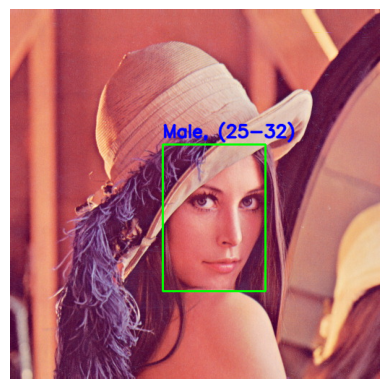

In [43]:
import cv2 as cv
import numpy as np
import os
import urllib.request
import matplotlib.pyplot as plt

def is_valid_file(path, min_size=10000):
    return os.path.exists(path) and os.path.getsize(path) > min_size

def download_file(filename, url, target_size):
    if not is_valid_file(filename, target_size):
        print(f"Downloading {filename}...")
        if os.path.exists(filename): os.remove(filename)
        opener = urllib.request.build_opener()
        opener.addheaders = [('User-agent', 'Mozilla/5.0')]
        urllib.request.install_opener(opener)
        urllib.request.urlretrieve(url, filename)

# Updated URLs for the models
models = {
    "age_deploy.prototxt": "https://raw.githubusercontent.com/GilLevi/AgeGenderDeepLearning/master/age_net_definitions/deploy.prototxt",
    "age_net.caffemodel": "https://github.com/GilLevi/AgeGenderDeepLearning/raw/master/models/age_net.caffemodel",
    "gender_deploy.prototxt": "https://raw.githubusercontent.com/GilLevi/AgeGenderDeepLearning/master/gender_net_definitions/deploy.prototxt",
    "gender_net.caffemodel": "https://github.com/GilLevi/AgeGenderDeepLearning/raw/master/models/gender_net.caffemodel",
    "deploy.prototxt": "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
    "res10_300x300_ssd_iter_140000.caffemodel": "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
    "lena.jpg": "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
}

for filename, url in models.items():
    target_size = 10000 if filename.endswith('.caffemodel') else 100
    try:
        download_file(filename, url, target_size)
    except Exception as e:
        print(f"Failed to download {filename}: {e}")

MODEL_MEAN_VALUES = (78.42628377603, 87.768914374447, 114.895847746128)
genderList = ['Male', 'Female']
ageList = ['(0-2)', '(4-6)', '(8-12)', '(15-20)', '(25-32)', '(38-43)', '(48-53)', '(60-100)']

def getFaceBox(net, frame, conf_threshold=0.7):
    frameOpencvDnn = frame.copy()
    frameHeight, frameWidth = frame.shape[:2]
    blob = cv.dnn.blobFromImage(frameOpencvDnn, 1.0, (300, 300), [104, 117, 123], True, False)
    net.setInput(blob)
    detections = net.forward()
    bboxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * frameWidth)
            y1 = int(detections[0, 0, i, 4] * frameHeight)
            x2 = int(detections[0, 0, i, 5] * frameWidth)
            y2 = int(detections[0, 0, i, 6] * frameHeight)
            bboxes.append([x1, y1, x2, y2])
            cv.rectangle(frameOpencvDnn, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return frameOpencvDnn, bboxes

try:
    ageNet = cv.dnn.readNet("age_net.caffemodel", "age_deploy.prototxt")
    genderNet = cv.dnn.readNet("gender_net.caffemodel", "gender_deploy.prototxt")
    faceNet = cv.dnn.readNet("res10_300x300_ssd_iter_140000.caffemodel", "deploy.prototxt")

    img = cv.imread('lena.jpg')
    frameFace, bboxes = getFaceBox(faceNet, img)
    if bboxes:
        for bbox in bboxes:
            x1, y1, x2, y2 = bbox
            face_img = img[max(0, y1):min(y2, img.shape[0]), max(0, x1):min(x2, img.shape[1])]
            blob = cv.dnn.blobFromImage(face_img, 1.0, (227, 227), MODEL_MEAN_VALUES, swapRB=False)
            genderNet.setInput(blob)
            gender = genderList[genderNet.forward()[0].argmax()]
            ageNet.setInput(blob)
            age = ageList[ageNet.forward()[0].argmax()]
            label = f"{gender}, {age}"
            cv.putText(frameFace, label, (x1, y1-10), cv.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2, cv.LINE_AA)
            print(f"Detection Success! Gender: {gender}, Age: {age}")

    cv.imwrite("output.jpg", frameFace)
    plt.imshow(cv.cvtColor(frameFace, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Inference Error: {e}")

In [51]:
try:
    # Using a different reliable URL for a sample image
    img_path = 'people.jpg'
    img_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/group.jpg"

    # Redownload to ensure file integrity
    print(f"Downloading {img_path} from a reliable source...")
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-agent', 'Mozilla/5.0')]
    urllib.request.install_opener(opener)
    urllib.request.urlretrieve(img_url, img_path)

    # Load image
    img_people = cv.imread(img_path)

    if img_people is None:
        print(f"Error: Failed to load {img_path}. Check if the file is valid.")
    else:
        frameFace, bboxes = getFaceBox(faceNet, img_people)

        if not bboxes:
            print("No faces detected in the image.")
        else:
            for bbox in bboxes:
                x1, y1, x2, y2 = bbox
                face_img = img_people[max(0, y1):min(y2, img_people.shape[0]), max(0, x1):min(x2, img_people.shape[1])]

                if face_img.size == 0: continue

                blob = cv.dnn.blobFromImage(face_img, 1.0, (227, 227), MODEL_MEAN_VALUES, swapRB=False)

                genderNet.setInput(blob)
                gender = genderList[genderNet.forward()[0].argmax()]

                ageNet.setInput(blob)
                age = ageList[ageNet.forward()[0].argmax()]

                label = f"{gender}, {age}"
                cv.putText(frameFace, label, (x1, y1-10), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2, cv.LINE_AA)
                print(f"Detected: {gender}, {age}")

        # Display result
        plt.figure(figsize=(12, 10))
        plt.imshow(cv.cvtColor(frameFace, cv.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Age and Gender Detection Test')
        plt.show()
except Exception as e:
    print(f"An error occurred: {e}")

An error occurred: HTTP Error 404: Not Found
